# 01 - Exploratory Data Analyst

## Yelp Review Rating Prediction
Goal: understand the text and label distribution before modeling. Specifically: </br>
* How imbalanced are the star ratings?
* How long are reviews, and does length vary by rating?
* What words/phrases characterize each rating level?
* Any data quality issues (empty reviews, duplicates, non-English text)?</br>

Every plot below should end with a **one-line written takeaway**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load data
The Yelp Review Full dataset ships as `train.csv/test.csv` with **no header row** and two columns: `label` (1-5 star rating) and `text`. Renaming `label` to `stars` here for clarity/consistency with the rest of this project.
`test.csv` is intentionally **not loaded anywhere in this notebook**, it's reserved as a geniune held-out test set, used only once at the very end in notebook 05. Working only from `train.csv` from here on.

In [2]:
df_full = pd.read_csv("../data/raw/train.csv", header=None, names=["stars", "text"])
df_full.drop(0, inplace=True)
print("Full train.csv shape:", df_full.shape)
df_full.head()

Full train.csv shape: (650000, 2)


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_4019/3689900380.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv("../data/raw/train.csv", header=None, names=["stars", "text"])


,stars,text
1,5,dr. goldberg offers everything i look for in a...
2,2,"Unfortunately, the frustration of being Dr. Go..."
3,4,Been going to Dr. Goldberg for over 10 years. ...
4,4,Got a letter in the mail last week that said D...
5,1,I don't know what Dr. Goldberg was like before...


In [3]:
df_full['stars'] = df_full['stars'].astype(int)

## 2. Subsample for a manageable working set
650K rows is more than needed for EDA-through-modeling at a casual pace, and would slow down transformer fine-tuning later. Taking a **stratified** sample (proportional per star rating) keeps the class balance identical to the full dataset, just smaller. So nothing about the imbalance story below is an artifact of sampling.

In [4]:
SAMPLE_SIZE = 18000 #can be adjusted up/down depending on how much time you have
df = (
    df_full.groupby("stars", group_keys=False)
    .apply(lambda x: x.sample(
        frac=SAMPLE_SIZE/len(df_full), random_state=42
    ))
    .reset_index(drop=True)
)

print("Working sample shape:", df.shape)
print('\nClass proportions match the full dataset:')
print(pd.DataFrame({
    "full_train": df_full['stars'].value_counts(normalize=True).sort_index(),
    "sample": df['stars'].value_counts(normalize=True).sort_index(),
}).round(3))

#saving the sample so later notebooks don't need to re-load and re-sample the full 
#dataset every time
df.to_csv("../data/processed/eda_sample.csv", index=False)

Working sample shape: (18000, 2)

Class proportions match the full dataset:
       full_train  sample
stars                    
1             0.2     0.2
2             0.2     0.2
3             0.2     0.2
4             0.2     0.2
5             0.2     0.2


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_4019/2900836777.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


## 3.Basic structure and missingness

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   stars   18000 non-null  int64 
 1   text    18000 non-null  object
dtypes: int64(1), object(1)
memory usage: 281.4+ KB


In [6]:
print("Missing values:")
print(df.isnull().sum())
print('\nDuplicate reviews:', df['text'].duplicated().sum())
print('Empty/whitespace-only reviews:', (df['text'].str.strip() == "").sum())

Missing values:
stars    0
text     0
dtype: int64

Duplicate reviews: 0
Empty/whitespace-only reviews: 0


In [7]:
# Duplicate reviews (still possible even with no missing values)
print("Exact duplicate reviews:", df["text"].duplicated().sum())

# Very short "reviews" that are barely text (e.g. just "Good.")
print("Reviews under 10 characters:", (df["text"].str.len() < 10).sum())

# Literal escaped newlines (`\n` as two characters, not an actual newline) —
# a known artifact of how this dataset was originally exported
print("Contains literal \\\\n:", df["text"].str.contains(r"\\n", regex=True).sum())

# Doubled/escaped quotes from CSV export
print("Contains doubled quotes:", df["text"].str.contains('""').sum())

Exact duplicate reviews: 0
Reviews under 10 characters: 7
Contains literal \\n: 9083
Contains doubled quotes: 0


While there aren't any duplicate reviews there are 7 short reviews (reviews with under 10 characters), and over 9K reviews with escaped newlines

# 4. Star rating distribution
This is the target. Here we will check how imbalanced it is, real review platform typically skew positive (more 4s and 5s than 1s and 2s).

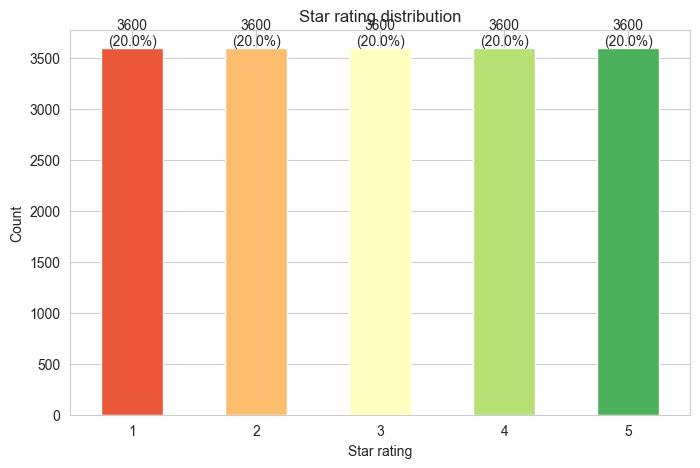

In [8]:
star_counts = df['stars'].value_counts().sort_index()
star_pct = df['stars'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots()
star_counts.plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', 5))
ax.set_xlabel('Star rating')
ax.set_ylabel('Count')
ax.set_title('Star rating distribution')
for i, (count, pct) in enumerate(zip(star_counts, star_pct)):
    ax.text(i, count, f"{count}\n({pct:.1f}%)", ha='center', va='bottom')
plt.xticks(rotation=0)
plt.show()

The reviews seem to be well-balanced across all star ratings 

# 5. Review length distribution
Character and word counts, both overall and split by rating - longer reviews might correlate with more extreme ratings (very happy or very upset customers write more).

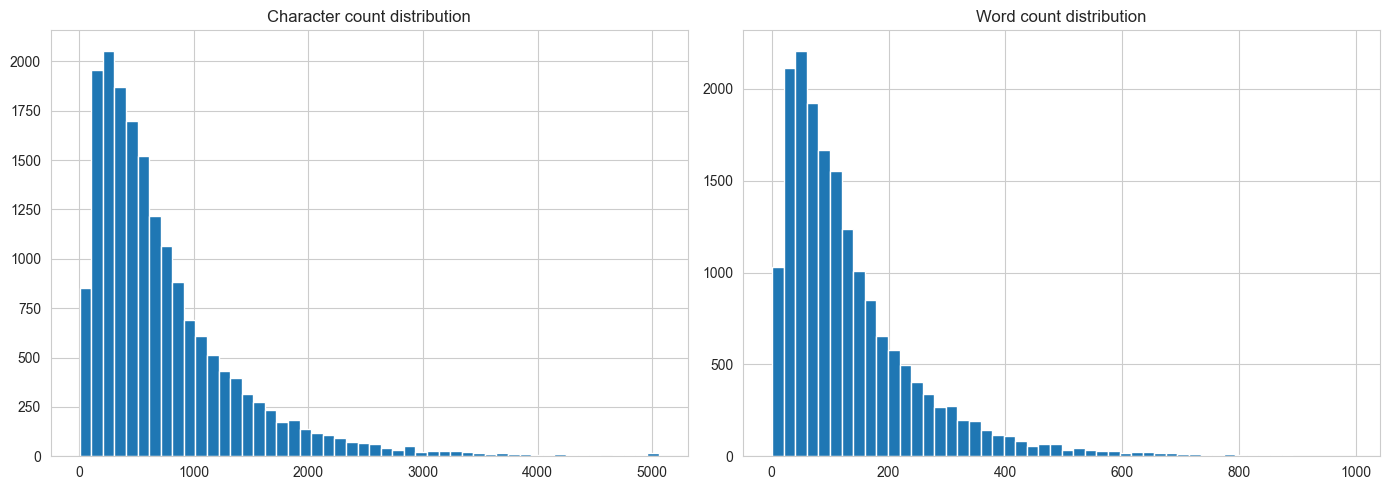

,char_count,word_count
count,18000.000000,18000.000000
mean,739.545278,135.433500
std,666.500621,121.971921
min,2.000000,1.000000
25%,289.750000,53.000000
50%,543.000000,100.000000
75%,964.250000,177.000000
max,5057.000000,991.000000


In [9]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['char_count'].hist(bins=50, ax=axes[0])
axes[0].set_title('Character count distribution')
df['word_count'].hist(bins=50, ax=axes[1])
axes[1].set_title("Word count distribution")
plt.tight_layout()
plt.show()

df[['char_count', 'word_count']].describe()

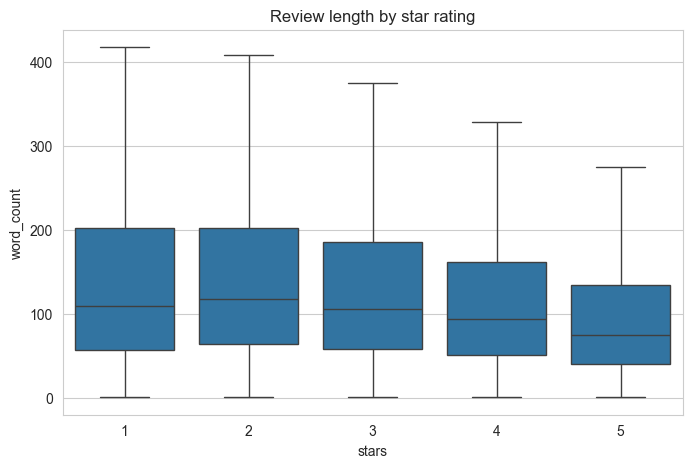

In [10]:
fig, ax = plt.subplots()
sns.boxplot(x='stars', y='word_count', data=df, ax=ax, showfliers=False)
ax.set_title("Review length by star rating")
plt.show()

The distribution between char count and word count are the same; interesting the higher rated reviews have less word counts on average than the lower rated reviews.

## 6. Word clouds by rating
This is a quick, visual way to spot characteristic vocabulary at each rating level - useful to sanity check before any formal modeling (e.g. 1-star reviews should show words like "worst", "never", "rude"; 5-star should show "amazing", "best", "love").

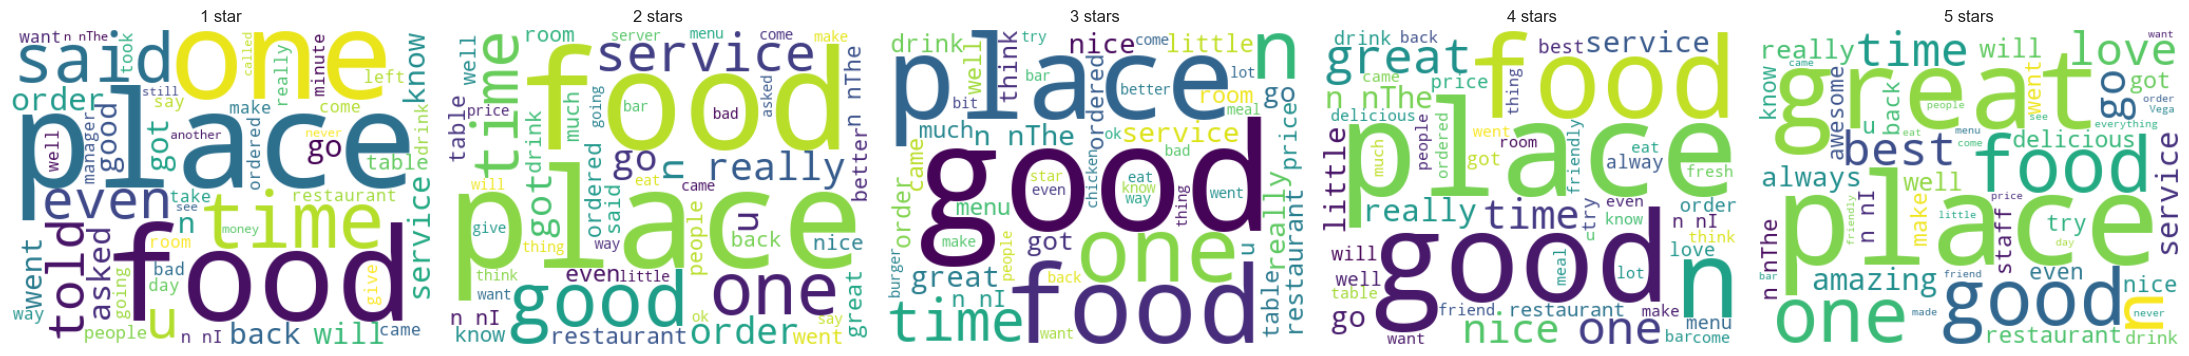

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, star in enumerate(range(1, 6)):
    text = " ".join(df.loc[df['stars'] == star, "text"].astype(str))
    wc = WordCloud(width=400, height=300, background_color='white', max_words=50).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"{star} star{'s' if star != 1 else ''}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In the 1-star and 2-star reviews, we see general words like "place", "food", "service" and in reviews 3-5 stars we can also see words like "place", but also "good", "great", "best", "nice", "love".

## 7. Most common words overall (informativeness check)
If very generic words dominate every rating equally, that's a signal stopword removal and/or TF-IDF (which naturally downweights common words) will matter a lot in notebook 02.

In [12]:
from collections import Counter

all_words = " ".join(df['text'].astype(str).str.lower()).split()
word_freq = Counter(all_words)
pd.DataFrame(word_freq.most_common(30), columns=['word', 'count'])

,word,count
0,the,121234
1,and,77252
2,a,62584
3,i,62170
4,to,59680
5,was,44056
6,of,36441
7,for,28003
8,it,27673
9,is,27106


## 8. Summary of Findings
* the classes are well balanced, with each review class ~20% of the dataset
* The dataset has no duplicate reviews, only 7 of the reviews have less than 10 characters, and over 9K have double escaped characters; the 50% double escaped characters suggest major cleaning in notebook 02
* the higher the rating, the less words there are in reviews on average 
* most 1-star or 2-star reviews have generic words, but reviews with 3+ rating use words like "good", "great", "best"